In [1]:
import os
import numpy as np
import cv2
from glob import glob 
from pathlib import Path

# to connect to the training resource
from azure.cognitiveservices.vision.customvision.training import CustomVisionTrainingClient

# to connect to the prediction resource
from azure.cognitiveservices.vision.customvision.prediction import CustomVisionPredictionClient

# to send the input files in batch; and to identify the object regions; for the training of the model.
from azure.cognitiveservices.vision.customvision.training.models import ImageFileCreateBatch, ImageFileCreateEntry, Region


from azure.identity import DefaultAzureCredential
from azure.mgmt.resource import ResourceManagementClient

# To authenticate the client
from msrest.authentication import ApiKeyCredentials
import os, uuid

# To read the local environment variables and secret keys
import os, dotenv
from dotenv import load_dotenv, find_dotenv

# To read the dataset
import pandas as pd

# to view images
from IPython.display import Image as img

# to process data in batches
import itertools

# to draw bounding boxes in local output.
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from IPython.display import Image
import numpy as np

from PIL import Image, ImageDraw
import PIL.Image

from IPython.display import clear_output 

from tqdm import tqdm
from time import sleep

## 1. Connect to the Custom Vision Service via created endopints and keys through environment file.

**Your enivironmental file should be like this**
 *ensure to mask your environment file by including it into gitignore folder*

    VISION_TRAINING_KEY="your training key"
    VISION_TRAINING_ENDPOINT="your training endpoint"
    VISION_TRAINING_RESOURCE_ID="your training resoruce ID"

    VISION_PREDICTION_KEY="your prediction key"
    VISION_PREDICTION_ENDPOINT="your prediction endpoint"
    VISION_PREDICTION_RESOURCE_ID="your prediction resource ID"


    ITERATION_ID= "your iteration ID"

    PROJECT_ID="your project ID"


    SUBSCRIPTION_ID = "your Subscription ID"
    RESOURCE_GROUP_NAME ="your resource group Name"

In [2]:
# Read the environment file to access your secret keys
load_dotenv("CVSKEP.env")

# Replace with valid values
VISION_TRAINING_ENDPOINT = os.environ["VISION_TRAINING_ENDPOINT"]
training_key = os.environ["VISION_TRAINING_KEY"]
prediction_key = os.environ["VISION_PREDICTION_KEY"]
prediction_resource_id = os.environ["VISION_PREDICTION_RESOURCE_ID"]
VISION_PREDICTION_ENDPOINT= os.environ["VISION_PREDICTION_ENDPOINT"]

## 2. Creating The Project (through SDK)

In [63]:
# create variables for your training resource
credentials = ApiKeyCredentials(in_headers={"Training-key": training_key})
trainer = CustomVisionTrainingClient(VISION_TRAINING_ENDPOINT, credentials)

# create variables for your prediction resource
prediction_credentials = ApiKeyCredentials(in_headers={"Prediction-Key": prediction_key})
predictor = CustomVisionPredictionClient(VISION_PREDICTION_ENDPOINT, prediction_credentials)

publish_iteration_name = "Vehicle_Detection"

# Find the object detection domain
obj_detection_domain = next(domain for domain in trainer.get_domains() if
                           domain.type == "ObjectDetection" and domain.name == "General")


In [ ]:

# Create a new project
print("Creating project...")
# Use uuid to avoid project name collisions.
project = trainer.create_project(publish_iteration_name,
                                domain_id=obj_detection_domain.id)

# Make tags in the new project
Car = trainer.create_tag(project.id, "Car")

## 3. Preparing the Frames 

### 3.1 Choosing the Videos from the Kaggle resource and setting the path

In [19]:
TaskPath=r"C:\07_Python_Projects\009_Custom_Vision_Model"

In [20]:
TrainVideos=["\Train-1.mov", "\Train-2.mov", "\Train-3.mov", "\Train-4.mov"]
TestVideos=["\Test-1.mov", "\Test-2.mov","\Test-3.mov"]

In [38]:
# Defining the Frame saving paths:
TestFramePath=TaskPath+"\Test_Frames"
TrainFramePath=TaskPath+"\Train_Frames"
TaggedTestFramePath=TaskPath+"\Tagged_testImage"

In [39]:
Path(TestFramePath).mkdir(exist_ok=True)
Path(TrainFramePath).mkdir(exist_ok=True)
Path(TaggedTestFramePath).mkdir(exist_ok=True)

### 3.2 Creating Frame Splitter 

In [40]:
def save_frame(videopath,savepath,videoname,gap):
    cap=cv2.VideoCapture(videopath)
    idx=0
    while True:
        ret,frame=cap.read()
        if ret==False:
            cap.release()
            break
        frame1 = cv2.flip(frame, 0)
        frame2=cv2.flip(frame1, 1)
        if idx==0:
            cv2.imwrite(f"{savepath}/{int(videoname)+idx}.png",frame2) 
        elif idx % gap ==0:
                cv2.imwrite(f"{savepath}/ {int(videoname)+idx}.png",frame2) 
        idx=idx+1

#### 3.2.1 Train Frames Stripping

In [42]:
for Trainvideo, framename in zip(TrainVideos, [0,1200,2400,3600]):
    print(Trainvideo,framename)
    save_frame(videopath=(TaskPath+Trainvideo),savepath=TrainFramePath,videoname=framename,gap=10)

\Train-1.mov 0
\Train-2.mov 1200
\Train-3.mov 2400
\Train-4.mov 3600


#### 3.2.2 Test Frames Stripping

In [43]:
for Testvideo, framename in zip(TestVideos, [0,1200,2400]):
    print(Testvideo,framename)
    save_frame((TaskPath+Testvideo),TestFramePath,framename,5)

\Test-1.mov 0
\Test-2.mov 1200
\Test-3.mov 2400


## 4. Publish the Model (Through SDK) -Ignore if already published in the Custom Vision Studio

In [58]:
credentials = ApiKeyCredentials(in_headers={"Training-key": training_key})
trainer = CustomVisionTrainingClient(VISION_TRAINING_ENDPOINT, credentials)
# Get all projects
projects = trainer.get_projects()

# Find your project by name
project = next(p for p in projects if p.name == "Vehicle_Detection")
# print("Project ID:", project.id)

In [59]:
# saving the best iteration
id = os.environ["ITERATION_ID"]
project.id=os.environ["PROJECT_ID"]

In [66]:
iterations = trainer.get_iterations(project.id)

iteration = iterations[0]   # since you said you have only one

if iteration.publish_name is None:
    trainer.publish_iteration(
        project.id,
        iteration.id,
        "FirstModel",
        prediction_resource_id
    )
    print("Iteration published")
else:
    print("Iteration already published as:", iteration.publish_name)

Iteration already published as: FirstModel


In [76]:
publish_iteration_name=iteration.publish_name

In [68]:
# # The iteration is now trained. Publish it to the project endpoint
# trainer.publish_iteration(project.id, id, publish_iteration_name, prediction_resource_id)
# print ("Done!")

## 5. Preview the result by testing

In [ ]:
# Now there is a trained endpoint that can be used to make a prediction
# Open the sample image and get back the prediction results.
with open(rf"{TaskPath}\Test_Frames\ 20.png",
            mode="rb") as test_data:
  results = predictor.detect_image(project.id, publish_iteration_name, test_data)

# Display the results.
for prediction in results.predictions:
  print("\t" + prediction.tag_name + ": {0:.2f}% bbox.left = {1:.2f}, bbox.top = {2:.2f}, bbox.width = {3:.2f}, bbox.height = {4:.2f}".format(
          prediction.probability * 100, prediction.bounding_box.left,
          prediction.bounding_box.top, prediction.bounding_box.width,
          prediction.bounding_box.height))

	Car: 62.19% bbox.left = 0.90, bbox.top = 0.34, bbox.width = 0.10, bbox.height = 0.15
	Car: 10.62% bbox.left = 0.06, bbox.top = 0.54, bbox.width = 0.05, bbox.height = 0.08
	Traffic Light Green: 8.45% bbox.left = 0.03, bbox.top = 0.31, bbox.width = 0.02, bbox.height = 0.07
	Traffic Light Green: 7.24% bbox.left = 0.36, bbox.top = 0.44, bbox.width = 0.02, bbox.height = 0.06
	Traffic Light Green: 5.84% bbox.left = 0.67, bbox.top = 0.00, bbox.width = 0.29, bbox.height = 0.62
	Car: 5.44% bbox.left = 0.00, bbox.top = 0.54, bbox.width = 0.04, bbox.height = 0.09
	Traffic Light Green: 4.45% bbox.left = 0.21, bbox.top = 0.43, bbox.width = 0.03, bbox.height = 0.08
	Car: 4.13% bbox.left = 0.48, bbox.top = 0.49, bbox.width = 0.04, bbox.height = 0.08
	Car: 4.11% bbox.left = 0.82, bbox.top = 0.28, bbox.width = 0.11, bbox.height = 0.24
	Traffic Light Red: 3.86% bbox.left = 0.03, bbox.top = 0.31, bbox.width = 0.02, bbox.height = 0.07
	Car: 3.72% bbox.left = 0.67, bbox.top = 0.00, bbox.width = 0.29, bbox

In [69]:
# Load a test image and get its dimensions
img_file = rf"{TaskPath}\Test_Frames\ 20.png"            
my_img = Image.open(img_file)
img_height, img_width, img_ch = np.array(my_img).shape

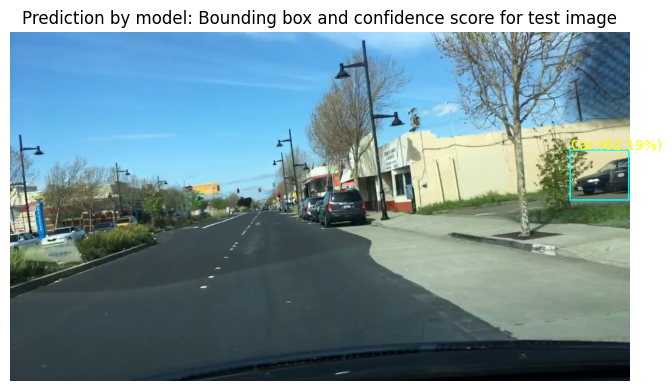

In [70]:
# Create a figure to display the results
fig = plt.figure(figsize=(8, 8))
plt.axis('off')
# Display the image
draw = ImageDraw.Draw(my_img)
# Select line width and color for the bounding box
lineWidth = int(img_width/100)
prediction_color = 'cyan'
# Display the results
for prediction in results.predictions:
    color = 'white' # default
    if (prediction.probability*100) > 50:
        left = prediction.bounding_box.left * img_width
        top = prediction.bounding_box.top * img_height
        height = prediction.bounding_box.height * img_height
        width =  prediction.bounding_box.width * img_width
        # Create a rectangle
        draw.rectangle((left, top, left+width, top+height), outline=prediction_color, width=3)#ineWidth)
        # Display tags and probabilities
        plt.annotate(f"{prediction.tag_name}:({prediction.probability * 100 :.2f}%)",(left,top),color='yellow')#, backgroundcolor=color)
plt.imshow(my_img)
plt.title("Prediction by model: Bounding box and confidence score for test image")
plt.show()

In [71]:
# Extracting the image names to save the tagged images with same name. 

imagenames=[]
for (root, dirs, file) in os.walk(TestFramePath):
    for f in file:
        if ('.png') in f:
            name=f.split(".")[0]
            imagenames.append(name)

In [72]:
len(imagenames)

726

In [73]:
imagenames

[' 10',
 ' 100',
 ' 1000',
 ' 1005',
 ' 1010',
 ' 1015',
 ' 1020',
 ' 1025',
 ' 1030',
 ' 1035',
 ' 1040',
 ' 1045',
 ' 105',
 ' 1050',
 ' 1055',
 ' 1060',
 ' 1065',
 ' 1070',
 ' 1075',
 ' 1080',
 ' 1085',
 ' 1090',
 ' 1095',
 ' 110',
 ' 1100',
 ' 1105',
 ' 1110',
 ' 1115',
 ' 1120',
 ' 1125',
 ' 1130',
 ' 1135',
 ' 1140',
 ' 1145',
 ' 115',
 ' 1150',
 ' 1155',
 ' 1160',
 ' 1165',
 ' 1170',
 ' 1175',
 ' 1180',
 ' 1185',
 ' 1190',
 ' 1195',
 ' 120',
 ' 1200',
 ' 1205',
 ' 1210',
 ' 1215',
 ' 1220',
 ' 1225',
 ' 1230',
 ' 1235',
 ' 1240',
 ' 1245',
 ' 125',
 ' 1250',
 ' 1255',
 ' 1260',
 ' 1265',
 ' 1270',
 ' 1275',
 ' 1280',
 ' 1285',
 ' 1290',
 ' 1295',
 ' 130',
 ' 1300',
 ' 1305',
 ' 1310',
 ' 1315',
 ' 1320',
 ' 1325',
 ' 1330',
 ' 1335',
 ' 1340',
 ' 1345',
 ' 135',
 ' 1350',
 ' 1355',
 ' 1360',
 ' 1365',
 ' 1370',
 ' 1375',
 ' 1380',
 ' 1385',
 ' 1390',
 ' 1395',
 ' 140',
 ' 1400',
 ' 1405',
 ' 1410',
 ' 1415',
 ' 1420',
 ' 1425',
 ' 1430',
 ' 1435',
 ' 1440',
 ' 1445',
 ' 145',
 '

In [78]:
for name in tqdm(imagenames):

  imagefile=TestFramePath+f"\{name}.png"

  with open(imagefile,
              mode="rb") as test_data:
    results = predictor.detect_image(project.id, publish_iteration_name, test_data)

  # Load a test image and get its dimensions
  img_file = imagefile            
  my_img = Image.open(img_file)
  img_height, img_width, img_ch = np.array(my_img).shape

  # Create a figure to display the results
  fig = plt.figure(figsize=(8, 8))
  plt.axis('off')
  # Display the image
  draw = ImageDraw.Draw(my_img)
  # Select line width and color for the bounding box
  #lineWidth = int(img_width/100)
  prediction_color = 'red'
  # Display the results
  for prediction in results.predictions:
      color = 'white' # default
      if (prediction.probability*100) > 30:
          left = prediction.bounding_box.left * img_width
          top = prediction.bounding_box.top * img_height
          height = prediction.bounding_box.height * img_height
          width =  prediction.bounding_box.width * img_width
          # Create a rectangle
          draw.rectangle((left, top, left+width, top+height), outline=prediction_color, width=3)
          # Display tags and probabilities
          plt.annotate(f"{prediction.tag_name}: {round(prediction.probability * 100)}%",(left,top),color='yellow')#, backgroundcolor=color)
  plt.imshow(my_img)
  plt.title("Prediction by model: Bounding box and confidence score for test image")
  plt.savefig(TaggedTestFramePath+f"\{name}.png")
  plt.show()
  sleep(1)
  clear_output(wait=True)

100%|██████████| 726/726 [24:11<00:00,  2.00s/it]


## 6. Stitching the tagged image Back to Video

In [87]:
# Video Generating function 
def generate_video(output_folder,video_name): 
    image_folder =TaggedTestFramePath # make sure to use your folder 
    video_path = os.path.join(output_folder, video_name)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')

    os.chdir(TaggedTestFramePath) 
      
    images = [img for img in os.listdir(image_folder) 
              if img.endswith(".jpg") or
                 img.endswith(".jpeg") or
                 img.endswith("png")]
    images=sorted(images,key=lambda x: int(x.split(".")[0]))

    # Array images should only consider 
    # the image files ignoring others if any 
    # print(images)  
  
    frame = cv2.imread(os.path.join(image_folder, images[0])) 
  
    # setting the frame width, height width 
    # the width, height of first image 
    height, width, layers = frame.shape   
  
    video = cv2.VideoWriter(video_path, fourcc, 5, (width, height))
  
    # Appending the images to the video one by one 
    for image in images:  
        video.write(cv2.imread(os.path.join(image_folder, image)))  
    
    # Deallocating memories taken for window creation 
    cv2.destroyAllWindows()  
    video.release()  # releasing the video generated 
  
  
# Calling the generate_video function 
generate_video(TaskPath,"taggedvideo.mp4") 

### Ensure Deleting the resource group using Delete_Resource_Group.ipynb

## 7. References

**Datasource from**: https://www.kaggle.com/datasets/robikscube/driving-video-with-object-tracking/data

**Video Stitch Reference**: https://www.geeksforgeeks.org/python-create-video-using-multiple-images-using-opencv/

**Video Merge Reference**:https://stackoverflow.com/questions/36967947/how-to-merge-two-videos

https://zulko.github.io/moviepy/getting_started/compositing.html

https://stackoverflow.com/questions/75656843/why-does-moviepy-stretch-my-output-after-cutting-and-putting-back-together-a-vid